## Dataset

#### In this part of the notebook I load all necessary data and create divide data in 3 parts for training, validation and test

I start by importing all necessary libraries and setting backend environment to tensorflow

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

Next, I need to load all images in corresponding libraries. Additionally I print amount of images in each class

In [ ]:
main_folder = 'raw_dataset/dataset'

banana1_folder = os.path.join(main_folder, '1st_class_banana')
apple1_folder = os.path.join(main_folder, '1st_class_apple')
orange1_folder = os.path.join(main_folder, '1st_class_oranges')

banana2_folder = os.path.join(main_folder, '2nd_class_banana')
apple2_folder = os.path.join(main_folder, '2nd_class_apple')
orange2_folder = os.path.join(main_folder, '2nd_class_orange')

banana3_folder = os.path.join(main_folder, 'rotten_banana')
apple3_folder = os.path.join(main_folder, 'rotten_apple')
orange3_folder = os.path.join(main_folder, 'rotten_orange')

# Check the number of images
print(f'1st class banana images: {len(os.listdir(banana1_folder))}')
print(f'1st class apple images: {len(os.listdir(apple1_folder))}')
print(f'1st class orange images: {len(os.listdir(orange1_folder))}')

print(f'2nd class banana images: {len(os.listdir(banana2_folder))}')
print(f'2nd class apple images: {len(os.listdir(apple2_folder))}')
print(f'2nd class orange images: {len(os.listdir(orange2_folder))}')

print(f'rotten banana images: {len(os.listdir(banana3_folder))}')
print(f'rotten apple images: {len(os.listdir(apple3_folder))}')
print(f'rotten orange images: {len(os.listdir(orange3_folder))}')

1st class banana images: 1962
1st class apple images: 2088
1st class orange images: 1853
2nd class banana images: 450
2nd class apple images: 441
2nd class orange images: 467
rotten banana images: 2748
rotten apple images: 2942
rotten orange images: 1998


As we can see on the output above, second class images lack a lot of data. We cannot train model with this many images, as our model will be statistically biased towards rotten and first class. That is why in the code block below I set maximum images per class to 440.

The cell below processes images below by resizing them to 128 by 128 size. Next, it stores images and class labels in X and y variables, respectively, and as mentioned above, does so only for first 440 images of each class. 

In [3]:
# Folder paths where the images of each class are stored
folder_paths = [
    apple1_folder,
    banana1_folder,
    orange1_folder,
    apple2_folder,
    banana2_folder,
    orange2_folder,
    apple3_folder,
    banana3_folder,
    orange3_folder
]

# Class labels for the images (same order as folder_paths)
class_names = [
    '1st_class_apple',
    '1st_class_banana',
    '1st_class_orange',
    '2nd_class_apple',
    '2nd_class_banana',
    '2nd_class_orange',
    'rotten_apple',
    'rotten_banana',
    'rotten_orange'
]

# Target size to resize the images
target_size = (128, 128)

# Maximum number of images to load per class
# Since I have only ~450 AI-generated images for each "second class" class, and the rest is over ~2000 for each other class, I will only use max of 440 images per class 
max_images_per_class = 440
max_total_size = len(class_names) * max_images_per_class

# Arrays to store the images (X) and class labels (y)
X = []
y = []

for i in range(len(folder_paths)):
    if len(X) == max_total_size: break
    count = 0
    for filename in os.listdir(folder_paths[i]):
        if count >= max_images_per_class:
            break
        file_extension = os.path.splitext(filename)[1].lower()
        if file_extension in (".jpg", ".jpeg", ".png"):
            image_filename = os.path.join(folder_paths[i], filename)
            try:
                # Read the image file using scikit-image
                image = ski.io.imread(image_filename)
                # Resize the image to the target_size
                image_resized = ski.transform.resize(image, target_size)
                # Insert the image into array X
                X.append(image_resized)
                # Insert the class label into array y
                y.append(class_names[i])
                count += 1
            except Exception as e:
                print(f"Error loading image {image_filename}: {e}")

# Convert arrays into numpy arrays
X = np.array(X)
y = np.array(y)

print(f'Total images loaded: {len(X)}')
print(f'Image shape: {X[0].shape}')
print(f'Labels shape: {y.shape}')
print(f'\nImages per class:')
for name in class_names:
    print(f'  {name}: {np.sum(y == name)}')


Total images loaded: 3960
Image shape: (128, 128, 3)
Labels shape: (3960,)

Images per class:
  1st_class_apple: 440
  1st_class_banana: 440
  1st_class_orange: 440
  2nd_class_apple: 440
  2nd_class_banana: 440
  2nd_class_orange: 440
  rotten_apple: 440
  rotten_banana: 440
  rotten_orange: 440


After storing all data in X and y matrices, we need to split it in train, validation and test sets. The cell below splits data in 80:10:10 ratio, respectively.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 1/10,
                                                    random_state = 0)
                                                    
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size = 1/9,
                                                  random_state = 0)
                                                  

print(f'Training set size: {len(X_train)}')
print(f'Validation set size: {len(X_val)}')
print(f'Test set size: {len(X_test)}')

Training set size: 3168
Validation set size: 396
Test set size: 396


# None of iterations have random seed, so results are slightly different for every time a model is run!

## Iteration 1: Basic Convolutional Neural Network

### A: Preprocessing

Before we can feed the data in the neural network, we need to encode labels by applying one-hot encoding technique. The cell below transforms y matrices by applying label encoder and one-hot encoding labels afterwards.

In [5]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
label_encoder = LabelEncoder()

label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f'Unique labels in y_train: {np.unique(y_train)}')

y_train_encoded = to_categorical(label_encoder.transform(y_train), num_classes=9)
y_val_encoded = to_categorical(label_encoder.transform(y_val), num_classes=9)
y_test_encoded = to_categorical(label_encoder.transform(y_test), num_classes=9)

print(f'Encoded y_train sample: {y_train_encoded[:10]}')
print(f'Encoded y_train sample: {y_val_encoded[:10]}')
print(f'Encoded y_train sample: {y_test_encoded[:10]}')


Unique labels in y_train: ['1st_class_apple' '1st_class_banana' '1st_class_orange' '2nd_class_apple'
 '2nd_class_banana' '2nd_class_orange' 'rotten_apple' 'rotten_banana'
 'rotten_orange']
Encoded y_train sample: [[0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 

### B: CNN Architecture

The cell below defines CNN architecture.

My CNN architecture consists of:
- An input layer of shape (128, 128, 3)
- 3 convolutional layers with kernel size of 3, ReLU activation functions and number of filters equal to 64, 128 and 256, respectively
- 3 max pooling layers with pool size of 2 by 2
- A flattening layer
- A dense layer with 128 units and ReLU activation function
- A dropout layer with 0.5 rate
- An output layer with 9 units and softmax activation function

I decided to use such number of filters in my convolutional layers, because they enable complex analysis and are not too computationally expensive. Additionally, units in powers of 2 align with binary architecture of computer memory.

The pool size has size of 2 by 2 so it does both, keep as much information of an image as possible, but reduces number of parameters as well.

Flatten layer converts matrix in a 1D vector for further processing.

The dense layer has 128 units for same reasons as convolutional layers, to be both computationally promising and memory efficient.

The dropout layer has rate of 0.5 to prevent model from overfitting as much as possible.

The output layer has 9 units, as much as there are different labels in the dataset.

In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

def build_cnn_model(print_summary=False):
    model = Sequential()

    model.add(Input(shape=(128,128,3)))

    model.add(Conv2D(64, kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Conv2D(128, kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(256, kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(9, activation='softmax'))

    
    if print_summary:
        model.summary()
    
    return model

# Build and display the model
model = build_cnn_model(print_summary=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,794,633 (25.92 MB)

 Trainable params: 6,794,633 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

### C: CNN Training

Cells below compile and train the model.

First cell defines model compilation parameters and compiles the model. I use categorical cross entropy as loss function since I have 9 classes, adam as optimizer algorithm, and accuracy as a metric to observe. This is a standard and effective set of parameters, so I did not make any changes

In [7]:
def compile_cnn_model(model):
    
    # Compile the model with binary_crossentropy loss, adam optimizer, and accuracy metric
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model

model = compile_cnn_model(model)

The next cell trains the model with early stopping callback, to stop the model at right moment and prevent overfitting. I chose patience of 4 to train the model more, and stop training only after 4 epochs of worsening results.

As for the parameters I used to train the model, I used batch size of 16 to make it easier for the model to train, 30 epochs with early stopping to train more and prevent overfitting.

In [8]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(patience=4)
H = model.fit(X_train, y_train_encoded, validation_data=(X_val, y_val_encoded), batch_size=16, validation_batch_size=16, epochs=30, callbacks=[early_stopping])

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 54s 257ms/step - accuracy: 0.5432 - loss: 1.2496 - val_accuracy: 0.7652 - val_loss: 0.6361
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 49s 249ms/step - accuracy: 0.7487 - loss: 0.6890 - val_accuracy: 0.8763 - val_loss: 0.3518
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 50s 251ms/step - accuracy: 0.8229 - loss: 0.4827 - val_accuracy: 0.8763 - val_loss: 0.3313
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 50s 252ms/step - accuracy: 0.8368 - loss: 0.4537 - val_accuracy: 0.8939 - val_loss: 0.3005
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 49s 248ms/step - accuracy: 0.8602 - loss: 0.3871 - val_accuracy: 0.9167 - val_loss: 0.2511
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 52s 263ms/step - accuracy: 0.8908 - loss: 0.3113 - val_accuracy: 0.9066 - val_loss: 0.2448
Epoch 7/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 48s 245ms/step - accuracy: 0.9012 - loss: 0.2763 - val_accuracy: 0.9242 - val_loss: 0.2420
Epoch 8/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 47s 237ms/step - accuracy: 0.9047 - loss: 0

### D: Model Evaluation

In this part of notebook I evaluate the model by plotting loss and accuracy graphs and confusion matrix.

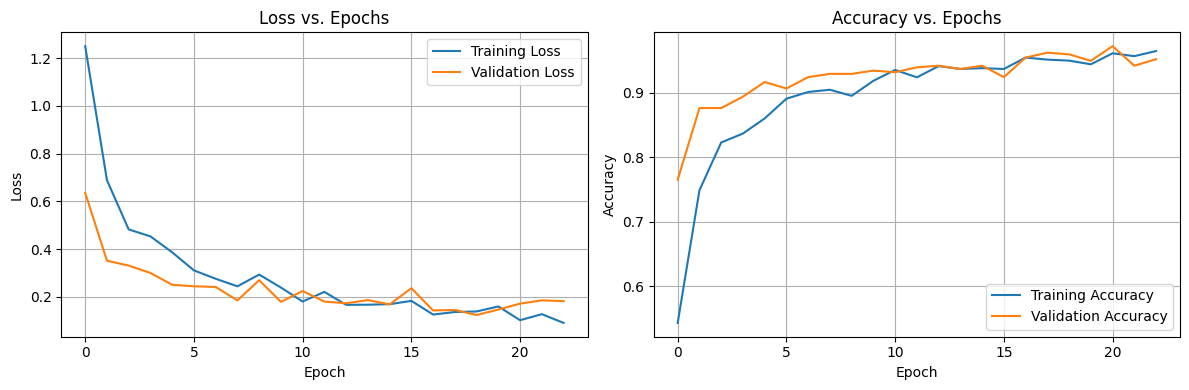

In [9]:
def plot_training_history(H):
    # Plot loss
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(H.history['loss'], label='Training Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epochs')
    plt.grid(True)
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(H.history['accuracy'], label='Training Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epochs')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(H)

Early stopping callback stopped model after 16 epochs. On the other hand, model has not converged yet in my opinion, and in the next iterations I should focus on that. 

Validation and training losses do not differ much (training loss of 0.128 vs. validation loss of 0.157) and accuracy is similar as well (training accuracy of 0.954 vs. validation accuracy 0.952)

In [10]:
test_loss, test_acc = model.evaluate(
    X_test, y_test_encoded
)

print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.9571 - loss: 0.1595
Test accuracy: 0.9571
Test loss: 0.1595


Using test set we can see that accuracy and loss is very similar to training and validaion results. In fact, test accuracy is even higher than training accuracy, and test loss is in-between best of training and validation losses.

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step


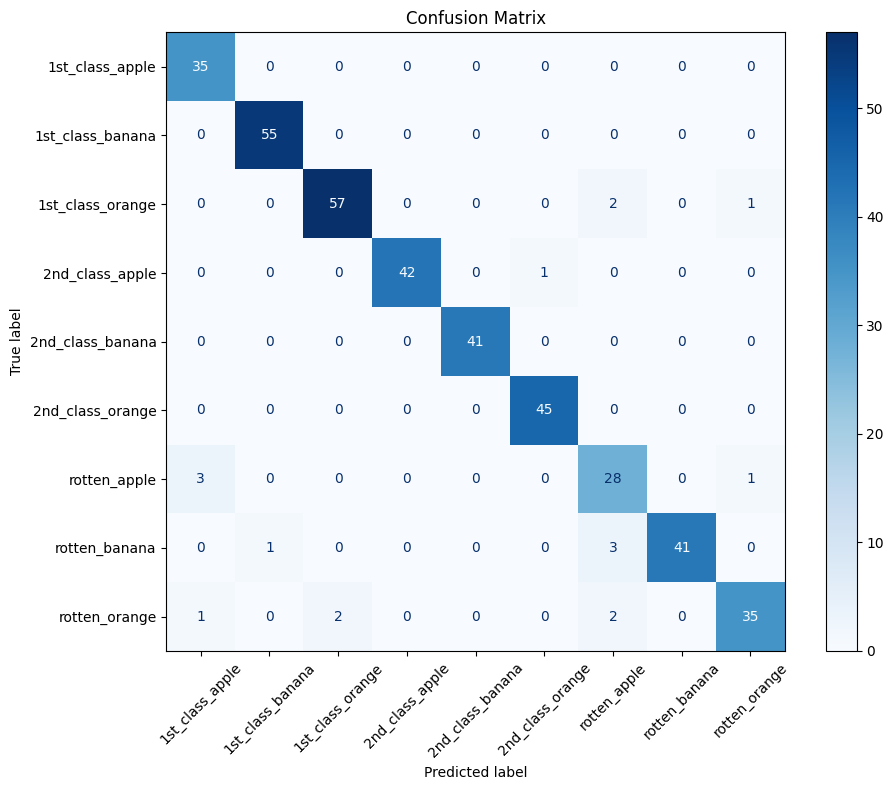

                  precision    recall  f1-score   support

 1st_class_apple       0.90      1.00      0.95        35
1st_class_banana       0.98      1.00      0.99        55
1st_class_orange       0.97      0.95      0.96        60
 2nd_class_apple       1.00      0.98      0.99        43
2nd_class_banana       1.00      1.00      1.00        41
2nd_class_orange       0.98      1.00      0.99        45
    rotten_apple       0.80      0.88      0.84        32
   rotten_banana       1.00      0.91      0.95        45
   rotten_orange       0.95      0.88      0.91        40

        accuracy                           0.96       396
       macro avg       0.95      0.95      0.95       396
    weighted avg       0.96      0.96      0.96       396



In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Make predictions on the test set (probabilities for each of the 9 classes)
y_pred_probs = model.predict(X_test)

# Convert probabilities to class index predictions using argmax
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Convert integer indices back to string labels to match y_test
y_pred_labels = label_encoder.inverse_transform(y_pred_indices)

# Create the confusion matrix (both y_test and y_pred_labels are strings)
cm = confusion_matrix(y_test, y_pred_labels, labels=class_names)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Per-class metrics using classification report
print(classification_report(y_test, y_pred_labels, labels=class_names))


On the confusion matrix we can see that the majority of classes were predicted correctly, with some minor exceptions, with orange class being the worst of them

Out of 59 predicted first class oranges only 56 were correct predictions, and out of 39 predicted rotten oranges only 35 were actually rotten. This results with 0.85 F1 score for rotten orange. Rotten apple class also a victim of incorrect prections, resulting in 0.89 F1 score.

Other than that, the results of confusion matrix are fine.

## Iteration 2: Data Augmentation

### A: Preprocessing

The main difference of this iteration from the iteration above is using data augmentation, that is, providing more data for the model to be trained on.

Most of the cells below are same as cells in iteration 1, except for the CNN architecture. which adds data augmentation layers.

In [12]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
label_encoder = LabelEncoder()

label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f'Unique labels in y_train: {np.unique(y_train)}')

y_train_encoded = to_categorical(label_encoder.transform(y_train), num_classes=9)
y_val_encoded = to_categorical(label_encoder.transform(y_val), num_classes=9)
y_test_encoded = to_categorical(label_encoder.transform(y_test), num_classes=9)

print(f'Encoded y_train sample: {y_train_encoded[:10]}')
print(f'Encoded y_train sample: {y_val_encoded[:10]}')
print(f'Encoded y_train sample: {y_test_encoded[:10]}')

Unique labels in y_train: ['1st_class_apple' '1st_class_banana' '1st_class_orange' '2nd_class_apple'
 '2nd_class_banana' '2nd_class_orange' 'rotten_apple' 'rotten_banana'
 'rotten_orange']
Encoded y_train sample: [[0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 

### B: CNN Architecture

CNN architecture for this iteration includes data augmentation layers, that are supposed to expand dataset. 

After initialiation of first layer, next 3 layers are data augmentation layers that flip, rotate and zoom image, respectively. This is the main difference between CNN architecture of iteration 1 and this iteration.

In [13]:
from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input,
    RandomFlip, RandomRotation, RandomZoom
)

def build_cnn_model(print_summary=False):
    model = Sequential()

    model.add(Input(shape=(128, 128, 3)))

    model.add(RandomFlip("horizontal_and_vertical"))
    model.add(RandomRotation(0.2))
    model.add(RandomZoom(0.1))

    model.add(Conv2D(64, kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Conv2D(128, kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(256, kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(9, activation='softmax'))

    if print_summary:
        model.summary()
    
    return model

# Build and display the model
model = build_cnn_model(print_summary=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,794,633 (25.92 MB)

 Trainable params: 6,794,633 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

### C: CNN Training

Model is compiled with same parameters, that is, categorical cross entropy, adam optimizer, and additionally shows accuracy metrics

In [14]:
def compile_cnn_model(model):
    
    # Compile the model with binary_crossentropy loss, adam optimizer, and accuracy metric
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model

model = compile_cnn_model(model)

Model is trained with same early stopping callback with rate of 4 epochs, and batch size of 16 and total epochs of 30.

In [15]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(patience=4)
H = model.fit(X_train, y_train_encoded, validation_data=(X_val, y_val_encoded), batch_size=16, validation_batch_size=16, epochs=30, callbacks=[early_stopping])

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 63s 301ms/step - accuracy: 0.3580 - loss: 1.6832 - val_accuracy: 0.6919 - val_loss: 0.9005
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 55s 276ms/step - accuracy: 0.5919 - loss: 1.0640 - val_accuracy: 0.7854 - val_loss: 0.6282
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 75s 239ms/step - accuracy: 0.6941 - loss: 0.8774 - val_accuracy: 0.8434 - val_loss: 0.5191
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 50s 250ms/step - accuracy: 0.7494 - loss: 0.7203 - val_accuracy: 0.8485 - val_loss: 0.3892
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 46s 232ms/step - accuracy: 0.7831 - loss: 0.6350 - val_accuracy: 0.8965 - val_loss: 0.3495
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 45s 228ms/step - accuracy: 0.8024 - loss: 0.5857 - val_accuracy: 0.8636 - val_loss: 0.4599
Epoch 7/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 45s 227ms/step - accuracy: 0.8172 - loss: 0.5206 - val_accuracy: 0.9116 - val_loss: 0.2879
Epoch 8/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 45s 228ms/step - accuracy: 0.8251 - loss: 0

### D: Model Evaluation

Below is the cell to plot loss vs. epochs, and accuracy vs. epochs.

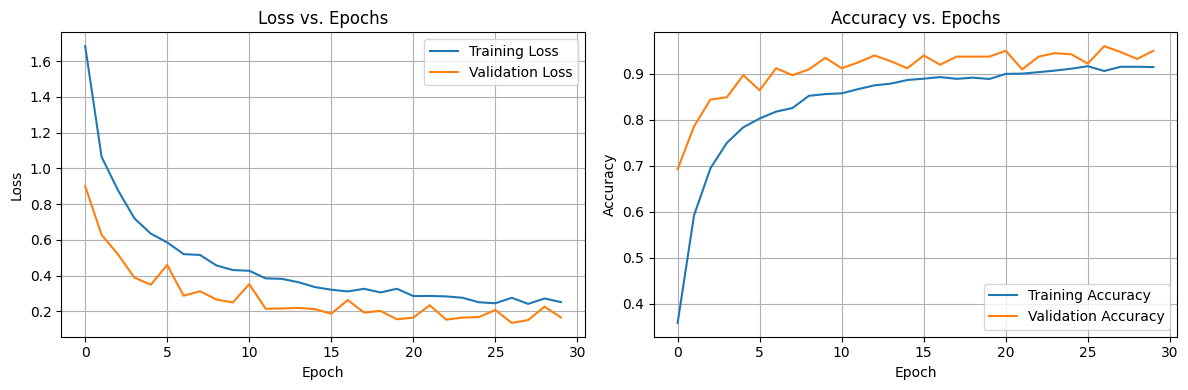

In [16]:
def plot_training_history(H):
    # Plot loss
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(H.history['loss'], label='Training Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epochs')
    plt.grid(True)
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(H.history['accuracy'], label='Training Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epochs')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(H)

Surprisingly, the loss and accuracy values got worse, compared to iteration 1 model.

Training loss increased dramatically, as well as validation loss.

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step


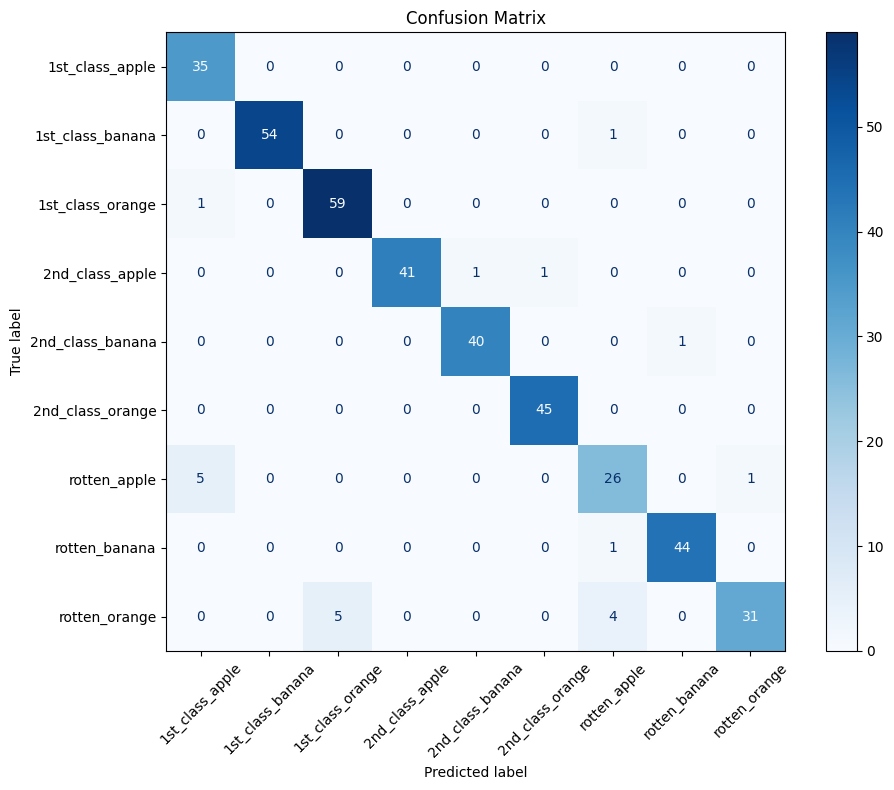

                  precision    recall  f1-score   support

 1st_class_apple       0.85      1.00      0.92        35
1st_class_banana       1.00      0.98      0.99        55
1st_class_orange       0.92      0.98      0.95        60
 2nd_class_apple       1.00      0.95      0.98        43
2nd_class_banana       0.98      0.98      0.98        41
2nd_class_orange       0.98      1.00      0.99        45
    rotten_apple       0.81      0.81      0.81        32
   rotten_banana       0.98      0.98      0.98        45
   rotten_orange       0.97      0.78      0.86        40

        accuracy                           0.95       396
       macro avg       0.94      0.94      0.94       396
    weighted avg       0.95      0.95      0.95       396



In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Make predictions on the test set (probabilities for each of the 9 classes)
y_pred_probs = model.predict(X_test)

# Convert probabilities to class index predictions using argmax
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Convert integer indices back to string labels to match y_test
y_pred_labels = label_encoder.inverse_transform(y_pred_indices)

# Create the confusion matrix (both y_test and y_pred_labels are strings)
cm = confusion_matrix(y_test, y_pred_labels, labels=class_names)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Per-class metrics using classification report
print(classification_report(y_test, y_pred_labels, labels=class_names))


Confusion matrix shows strong bias towards first class apple, rotten apple, and second class oranges, which proves decreased model performance.

In [18]:
test_loss, test_acc = model.evaluate(
    X_test, y_test_encoded
)

print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9470 - loss: 0.1073
Test accuracy: 0.9470
Test loss: 0.1073


The test accuracy improved from 95% to 96% and test improved as well.

Additionally, I will display some images of incorrectly classified fruits

Incorrectly classified images: 21 / 396


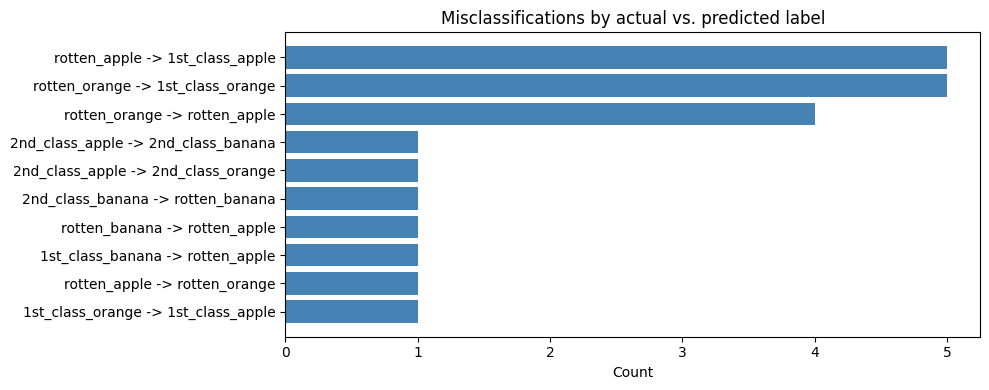

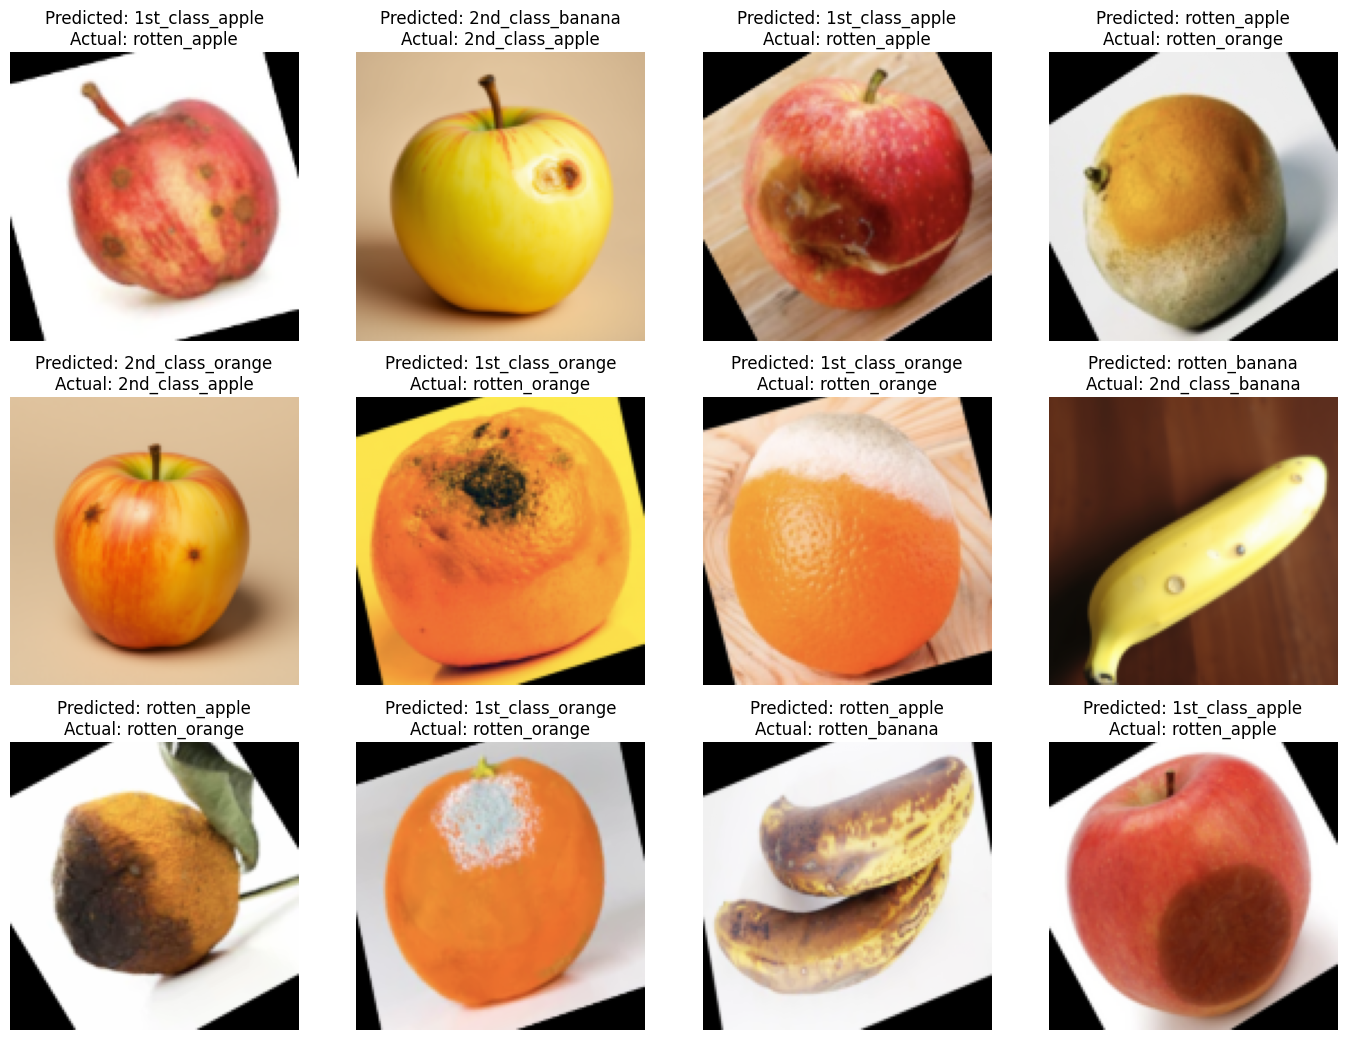

In [19]:
# Summarize and visualize misclassifications
mismatches = y_pred_labels != y_test
wrong_indices = np.where(mismatches)[0]
print(f"Incorrectly classified images: {len(wrong_indices)} / {len(y_test)}")

from collections import Counter
pair_counts = Counter(zip(y_test[mismatches], y_pred_labels[mismatches]))

if pair_counts:
    sorted_pairs = sorted(pair_counts.items(), key=lambda item: item[1], reverse=True)
    labels = [f"{actual} -> {predicted}" for (actual, predicted), _ in sorted_pairs]
    counts = [count for _, count in sorted_pairs]

    plt.figure(figsize=(10, max(4, 0.3 * len(labels))))
    plt.barh(labels, counts, color="steelblue")
    plt.gca().invert_yaxis()
    plt.xlabel("Count")
    plt.title("Misclassifications by actual vs. predicted label")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")

num_to_show = min(12, len(wrong_indices))
if num_to_show == 0:
    print("No misclassified images to display.")
else:
    cols = 4
    rows = int(np.ceil(num_to_show / cols))
    plt.figure(figsize=(cols * 3.5, rows * 3.5))
    for i, idx in enumerate(wrong_indices[:num_to_show]):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X_test[idx])
        plt.title(f"Predicted: {y_pred_labels[idx]}\nActual: {y_test[idx]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

We can see 5/14 incorrectly classified images are predicted rotten apples which were actually rotten oranges, and 3/14 were predicted 1st class oranges but in fact were rotten oranges. In total there are 8/14 images that had a label of rotten orange, but a model predicted them incorrectly. Additionally, we can see that all incorrectly classified images are data augmented, in this case they are rotated. Also, all of them except for 1 share the same plain white background.

## Iteration 3: Transfer Learning

### A: Preprocessing

The main difference of this iteration from the iteration above is using transfer learning, that is, using a pre-trained model.

Most of the cells below are same as cells in iteration 1, except for the CNN architecture that uses pre-trained model.

In [20]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
label_encoder = LabelEncoder()

label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f'Unique labels in y_train: {np.unique(y_train)}')

y_train_encoded = to_categorical(label_encoder.transform(y_train), num_classes=9)
y_val_encoded = to_categorical(label_encoder.transform(y_val), num_classes=9)
y_test_encoded = to_categorical(label_encoder.transform(y_test), num_classes=9)

print(f'Encoded y_train sample: {y_train_encoded[:10]}')
print(f'Encoded y_train sample: {y_val_encoded[:10]}')
print(f'Encoded y_train sample: {y_test_encoded[:10]}')

Unique labels in y_train: ['1st_class_apple' '1st_class_banana' '1st_class_orange' '2nd_class_apple'
 '2nd_class_banana' '2nd_class_orange' 'rotten_apple' 'rotten_banana'
 'rotten_orange']
Encoded y_train sample: [[0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 

### B: CNN Architecture

As mentioned above, pre-trained model is being used here.

In [21]:
import keras

base_model = keras.applications.MobileNet(
                include_top=False,
                weights='imagenet',
                input_shape=(128, 128, 3))
base_model.summary()


Model: "mobilenet_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 32, 32, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 32, 32, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,228,864 (12.32 MB)

 Trainable params: 3,206,976 (12.23 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [22]:
preprocessed_images_train = keras.applications.mobilenet.preprocess_input(X_train*255) 
output_features_train = base_model.predict(preprocessed_images_train)

preprocessed_images_val = keras.applications.mobilenet.preprocess_input(X_val*255) 
output_features_val = base_model.predict(preprocessed_images_val)

preprocessed_images_test = keras.applications.mobilenet.preprocess_input(X_test*255) 
output_features_test = base_model.predict(preprocessed_images_test)

99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step


In [23]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input

dense_model = Sequential()
dense_model.add(Input(shape=(4, 4, 1024)))
dense_model.add(Flatten())
dense_model.add(Dense(256, activation='relu'))
dense_model.add(Dense(128, activation='relu'))
dense_model.add(Dropout(rate=0.5))
dense_model.add(Dense(9, activation='softmax'))
dense_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,228,617 (16.13 MB)

 Trainable params: 4,228,617 (16.13 MB)

 Non-trainable params: 0 (0.00 B)

### C: CNN Training

The training process is also same as previous iterations, except for amount of epochs which is changed to 100 and early stopping patience rate is 8

In [24]:
from keras.callbacks import EarlyStopping

dense_model.compile(optimizer='adam', 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

callback = EarlyStopping(monitor='val_loss', 
                        patience=8, 
                        restore_best_weights=True)

H = dense_model.fit(output_features_train,
                y_train_encoded,
                batch_size=32,
                epochs=100,
                validation_data = (output_features_val, y_val_encoded),
                validation_batch_size=32,
                callbacks=[callback])


Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8381 - loss: 0.7031 - val_accuracy: 0.9672 - val_loss: 0.1196
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9542 - loss: 0.1473 - val_accuracy: 0.9949 - val_loss: 0.0146
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9741 - loss: 0.0849 - val_accuracy: 0.9773 - val_loss: 0.0755
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9830 - loss: 0.0556 - val_accuracy: 0.9949 - val_loss: 0.0188
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9848 - loss: 0.0504 - val_accuracy: 0.9975 - val_loss: 0.0166
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9848 - loss: 0.0535 - val_accuracy: 0.9848 - val_loss: 0.0355
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9921 - loss: 0.0305 - val_accuracy: 0.9924 - val_loss: 0.0154
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9956 - loss: 0.0139 - val_accuracy: 0.

### D: Model Evaluation

Training stopped on epoch 18, meaning validation loss stopped improving after epoch 10. So far pre-trained model allowed to achieve 99% training and validation accuracy

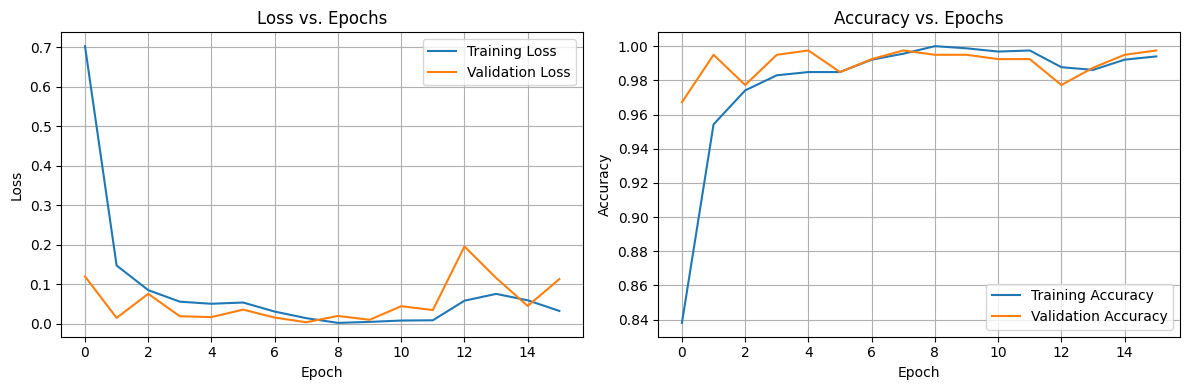

In [25]:
def plot_training_history(H):
    # Plot loss
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(H.history['loss'], label='Training Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epochs')
    plt.grid(True)
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(H.history['accuracy'], label='Training Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epochs')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(H)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


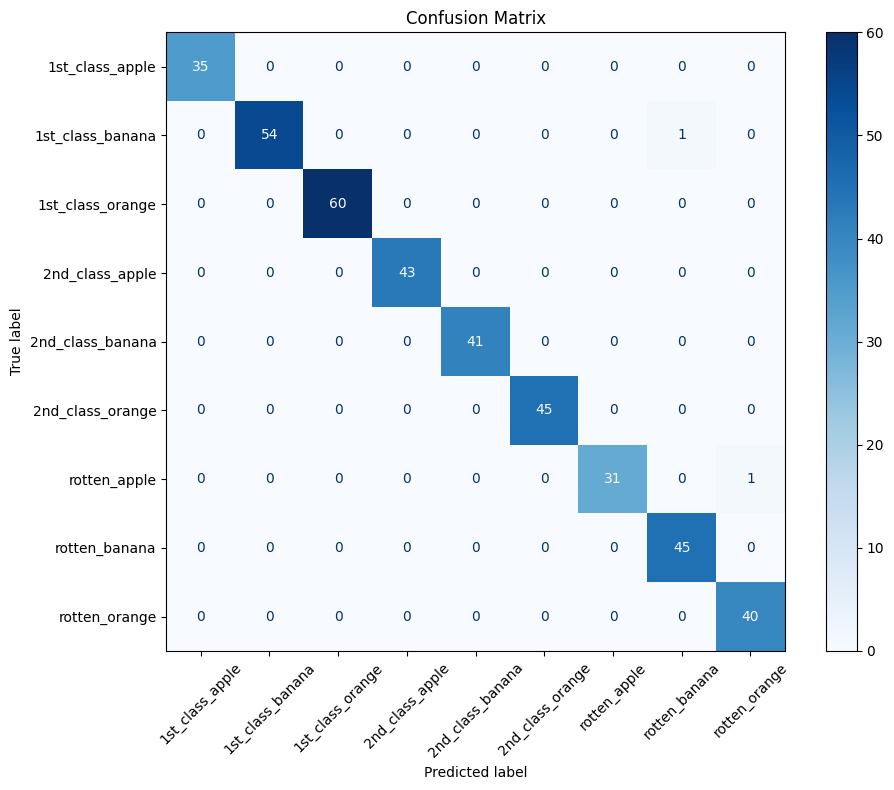

                  precision    recall  f1-score   support

 1st_class_apple       1.00      1.00      1.00        35
1st_class_banana       1.00      0.98      0.99        55
1st_class_orange       1.00      1.00      1.00        60
 2nd_class_apple       1.00      1.00      1.00        43
2nd_class_banana       1.00      1.00      1.00        41
2nd_class_orange       1.00      1.00      1.00        45
    rotten_apple       1.00      0.97      0.98        32
   rotten_banana       0.98      1.00      0.99        45
   rotten_orange       0.98      1.00      0.99        40

        accuracy                           0.99       396
       macro avg       0.99      0.99      0.99       396
    weighted avg       1.00      0.99      0.99       396



In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Make predictions on the test set (probabilities for each of the 9 classes)
y_pred_probs = dense_model.predict(output_features_test)

# Convert probabilities to class index predictions using argmax
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Convert integer indices back to string labels to match y_test
y_pred_labels = label_encoder.inverse_transform(y_pred_indices)

# Create the confusion matrix (both y_test and y_pred_labels are strings)
cm = confusion_matrix(y_test, y_pred_labels, labels=class_names)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Per-class metrics using classification report
print(classification_report(y_test, y_pred_labels, labels=class_names))

In [27]:
test_loss, test_acc = dense_model.evaluate(
    output_features_test, y_test_encoded
)

print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9949 - loss: 0.0140   
Test accuracy: 0.9949
Test loss: 0.0140


Model results are significantly better than iteration 1 and 2. In next iteration I will focus on decreasing the size of the model and reducing its computational needs

## Iteration 4: Model Improvement

### A: Preprocessing

Preprocessing step is the same as iteration 3. This iteration will focus on achieving similar or even better results, while reducing the neural network size

In [28]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
label_encoder = LabelEncoder()

label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f'Unique labels in y_train: {np.unique(y_train)}')

y_train_encoded = to_categorical(label_encoder.transform(y_train), num_classes=9)
y_val_encoded = to_categorical(label_encoder.transform(y_val), num_classes=9)
y_test_encoded = to_categorical(label_encoder.transform(y_test), num_classes=9)

print(f'Encoded y_train sample: {y_train_encoded[:10]}')
print(f'Encoded y_train sample: {y_val_encoded[:10]}')
print(f'Encoded y_train sample: {y_test_encoded[:10]}')

Unique labels in y_train: ['1st_class_apple' '1st_class_banana' '1st_class_orange' '2nd_class_apple'
 '2nd_class_banana' '2nd_class_orange' 'rotten_apple' 'rotten_banana'
 'rotten_orange']
Encoded y_train sample: [[0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Encoded y_train sample: [[0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 

### B: CNN Architecture

I will again use MobileNet CNN as pre-trained model

In [29]:
import keras

base_model = keras.applications.MobileNet(
                include_top=False,
                weights='imagenet',
                input_shape=(128, 128, 3))
base_model.summary()


Model: "mobilenet_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 32, 32, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 32, 32, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,228,864 (12.32 MB)

 Trainable params: 3,206,976 (12.23 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [30]:
preprocessed_images_train = keras.applications.mobilenet.preprocess_input(X_train*255) 
output_features_train = base_model.predict(preprocessed_images_train)

preprocessed_images_val = keras.applications.mobilenet.preprocess_input(X_val*255) 
output_features_val = base_model.predict(preprocessed_images_val)

preprocessed_images_test = keras.applications.mobilenet.preprocess_input(X_test*255) 
output_features_test = base_model.predict(preprocessed_images_test)

99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


However, this time I will use less nodes in dense layers. 

Previous iteration included 2 layers, with first layer consisting of 256 nodes, followed by a layer with 128 nodes. This time I will reduce number of nodes to 128 in first layer, and 32 nodes to second layer

In [31]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input

model = Sequential()
model.add(Input(shape=(4, 4, 1024)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(9, activation='softmax'))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,101,705 (8.02 MB)

 Trainable params: 2,101,705 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

As a result the CNN has 2 times less parameters (4 million vs. 2 million)

### C: CNN Training

Another feature I will implement in this iteration is a new callback function ```ReduceLROnPlateau```.

It will act like ```EarlyStopping```, but instead of stopping the model from training, it will reduce learning rate by a specified parameter ```factor``` and resume training. 

I will use this additional callback, because models often benefit from reducing the learning rate by a small factor once learning stagnates

In [32]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(optimizer='adam', 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

callback = EarlyStopping(monitor='val_loss', 
                        patience=8, 
                        restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                              patience=2, min_lr=0.0001)

H = model.fit(output_features_train,
                y_train_encoded,
                batch_size=32,
                epochs=100,
                validation_data = (output_features_val, y_val_encoded),
                validation_batch_size=32,
                callbacks=[callback, reduce_lr])


Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6360 - loss: 1.1367 - val_accuracy: 0.9141 - val_loss: 0.3145 - learning_rate: 0.0010
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7955 - loss: 0.6718 - val_accuracy: 0.9722 - val_loss: 0.1530 - learning_rate: 0.0010
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8605 - loss: 0.4498 - val_accuracy: 0.9545 - val_loss: 0.1802 - learning_rate: 0.0010
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8561 - loss: 0.4331 - val_accuracy: 0.9773 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9009 - loss: 0.2820 - val_accuracy: 0.9848 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9154 - loss: 0.2791 - val_accuracy: 1.0000 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9268 - loss: 0.2107 - 

### D: Model Evaluation

[Explain your strategy to evaluate the CNN model for this iteration here]

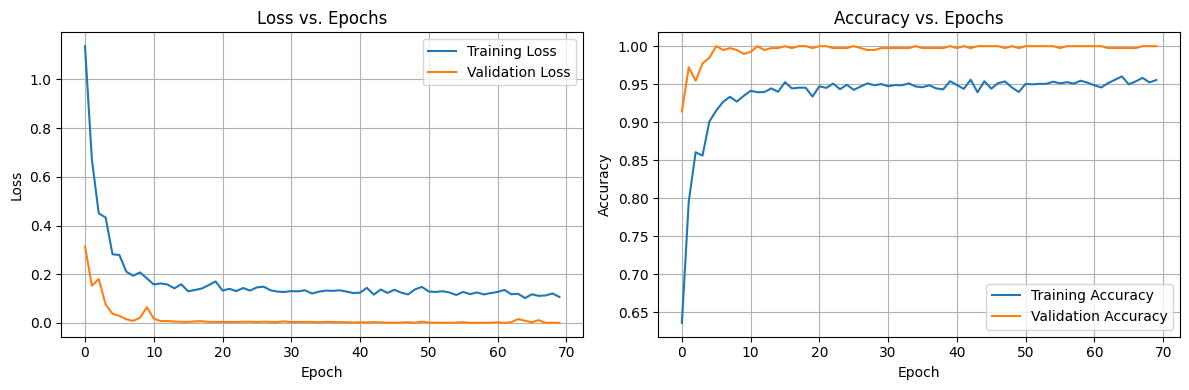

In [33]:
def plot_training_history(H):
    # Plot loss
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(H.history['loss'], label='Training Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epochs')
    plt.grid(True)
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(H.history['accuracy'], label='Training Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epochs')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(H)

Model stopped training on epoch 30, meaning that validation loss stopped improving on epoch 22. 

Surprisingly, validation accuracy and loss shows better results, than training accuracy and loss, which is unusual.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


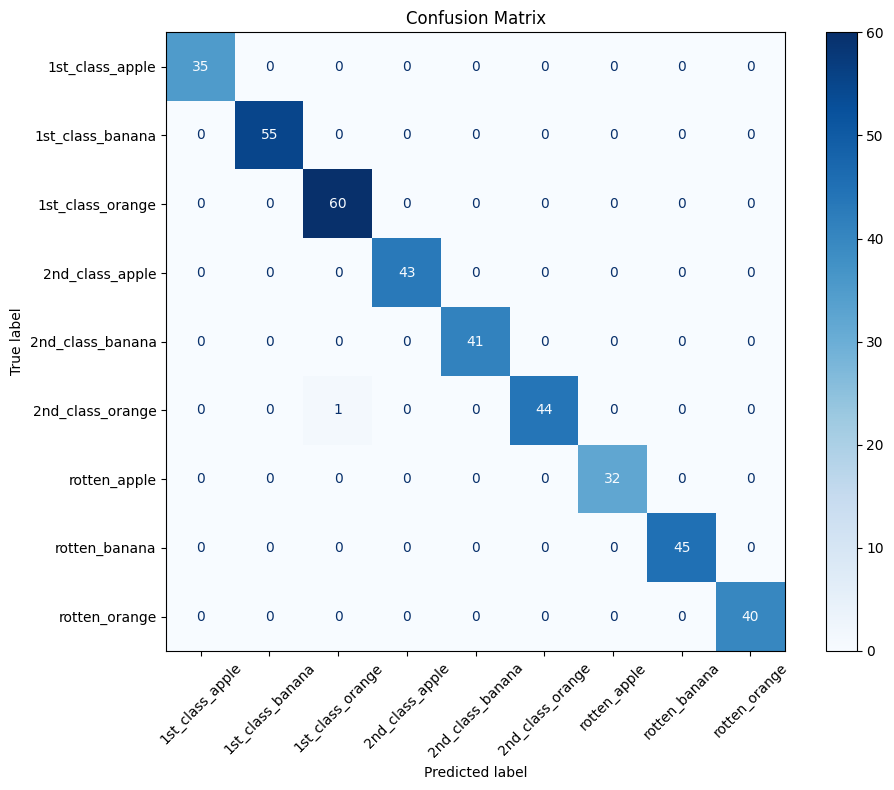

                  precision    recall  f1-score   support

 1st_class_apple       1.00      1.00      1.00        35
1st_class_banana       1.00      1.00      1.00        55
1st_class_orange       0.98      1.00      0.99        60
 2nd_class_apple       1.00      1.00      1.00        43
2nd_class_banana       1.00      1.00      1.00        41
2nd_class_orange       1.00      0.98      0.99        45
    rotten_apple       1.00      1.00      1.00        32
   rotten_banana       1.00      1.00      1.00        45
   rotten_orange       1.00      1.00      1.00        40

        accuracy                           1.00       396
       macro avg       1.00      1.00      1.00       396
    weighted avg       1.00      1.00      1.00       396



In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Make predictions on the test set (probabilities for each of the 9 classes)
y_pred_probs = model.predict(output_features_test)

# Convert probabilities to class index predictions using argmax
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Convert integer indices back to string labels to match y_test
y_pred_labels = label_encoder.inverse_transform(y_pred_indices)

# Create the confusion matrix (both y_test and y_pred_labels are strings)
cm = confusion_matrix(y_test, y_pred_labels, labels=class_names)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Per-class metrics using classification report
print(classification_report(y_test, y_pred_labels, labels=class_names))

In [35]:
test_loss, test_acc = model.evaluate(
    output_features_test, y_test_encoded
)

print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9975 - loss: 0.0051     
Test accuracy: 0.9975
Test loss: 0.0051


Using a test set on a model shows 100% accuracy with a loss of 0.004

Although the core idea behind this iteration was to reduce CNN size, apparently, likely due to ```ReduceLROnPlateau``` callback, the model achieved even better results